#### Ejercicio 1: Obtener una detección del logo en cada imagen sin falsos positivos

In [101]:
%matplotlib inline
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
import os

In [117]:
# Import template

template = cv.imread(r'/home/gaspi/CEIA_CV1_TP3/assets/template/pattern.png', cv.IMREAD_GRAYSCALE)

# Seteo path imagenes
path = '../assets/images'
images = [
    os.path.join(path, f)
    for f in os.listdir(path)
    if f.lower().endswith(('.png','.jpg','.jpeg'))
]
# filtramos multi 
images = [img for img in images if not img.endswith("multi.png")]

In [118]:
# Parámetros 
THRESH = 8
MIN_MATCH_COUNT = 6

In [119]:
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv.FlannBasedMatcher(index_params, search_params)

In [120]:
# Funcion de binarización (a mano)
def global_threshold(image, thres_value, val_high, val_low):
    img = image.copy()
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if image[i,j] > thres_value:
                img[i,j] = val_high
            else:
                img[i,j] = val_low
    return img

# Creamos el vector de características SIFT
sift = cv.SIFT_create()

In [121]:
def compute_score(kp1, des1, kp2, des2, ratio=0.6, ransac_th=3.0):
    if des1 is None or des2 is None:
        return 0, []

    matches = flann.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]

    if len(good) < MIN_MATCH_COUNT:
        return 0, good

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, ransac_th)

    score = int(mask.sum()) if mask is not None else 0
    return score, good

In [122]:
def evaluate_variants(templates, images, ratio=0.6, ransac_th=3.0):
    best_score = 0
    best_good = []
    best_data = (None, None, None, None)

    for tpl in templates:
        kp1, des1 = sift.detectAndCompute(tpl, None)

        for im in images:
            kp2, des2 = sift.detectAndCompute(im, None)

            score, good = compute_score(kp1, des1, kp2, des2, ratio, ransac_th)

            if score > best_score or (score == best_score and len(good) > len(best_good)):
                best_score = score
                best_good = good
                best_data = (kp1, kp2, tpl, im)

    return best_score, best_good, best_data

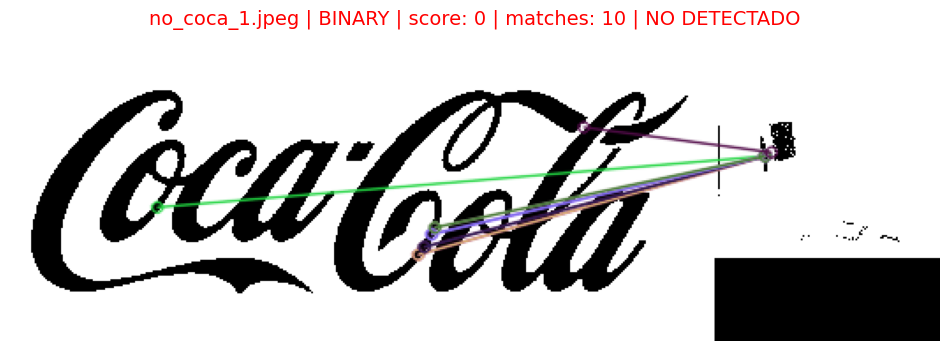

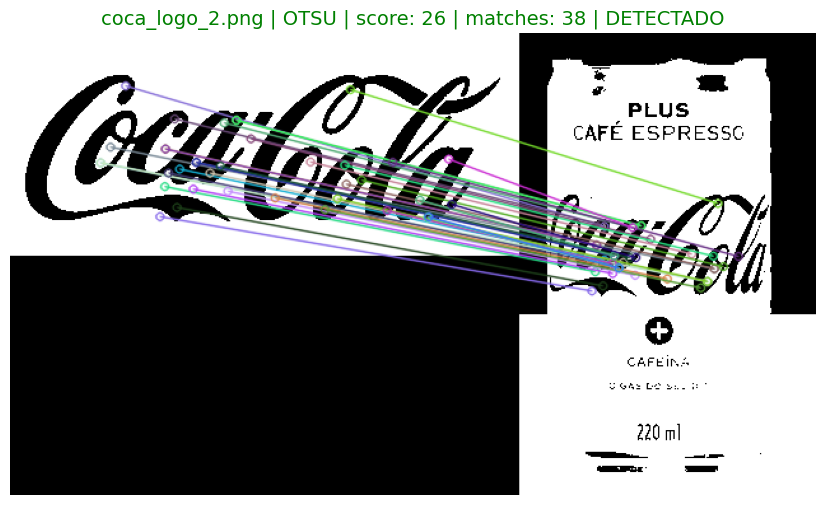

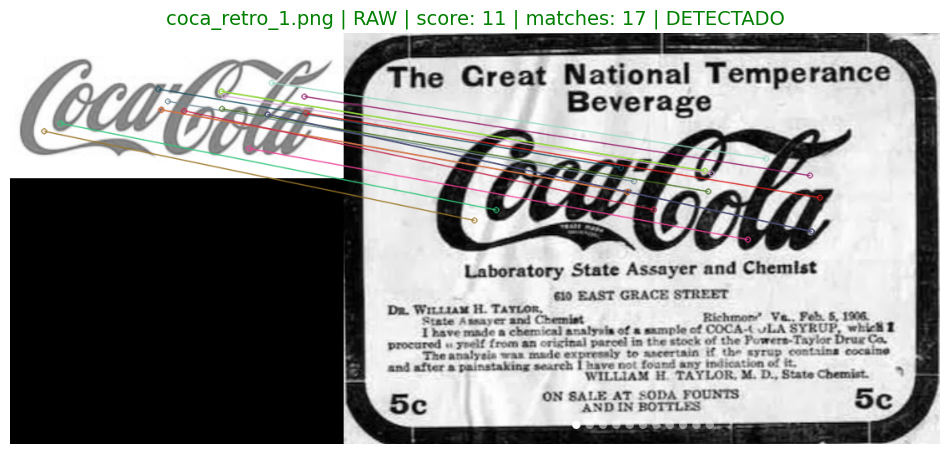

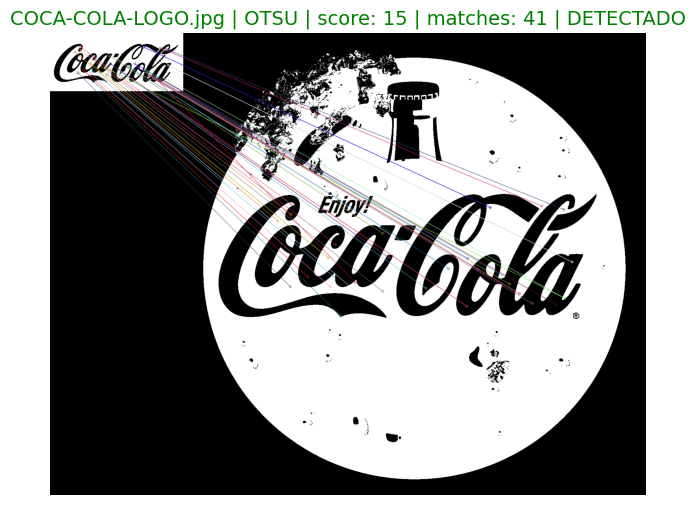

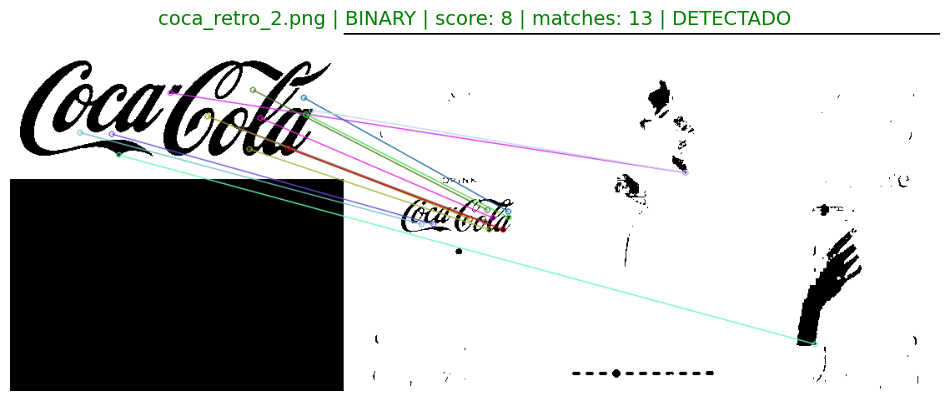

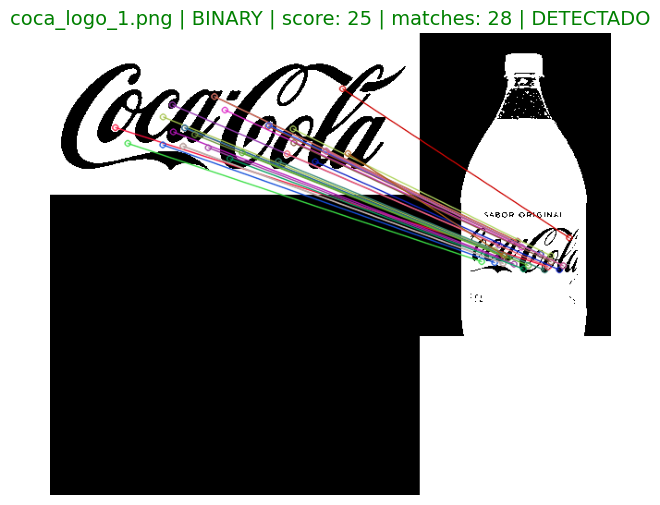

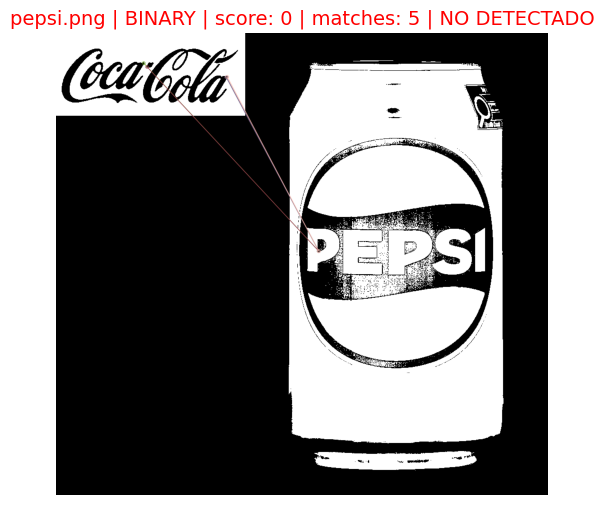

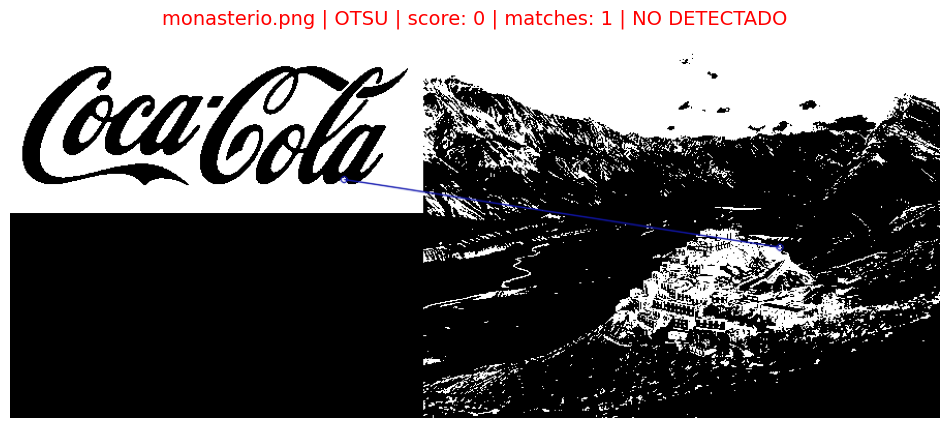

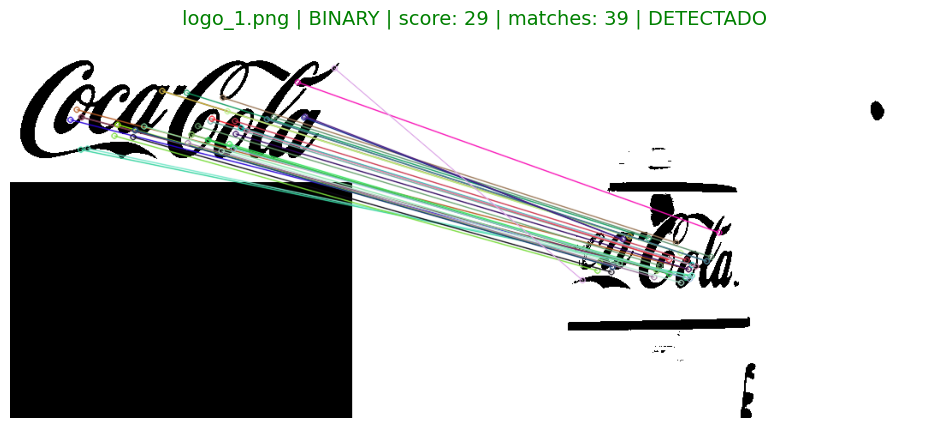

In [123]:

# Preprocesamos las variantes del template
# raw
kp1_raw, des1_raw = sift.detectAndCompute(template, None)
# inversa
template_inv = cv.bitwise_not(template)
# edges con canny
template_edges = cv.Canny(template_inv, 50, 150)
kp1_edge, des1_edge = sift.detectAndCompute(template_edges, None)
# binarización por otsu
_, template_otsu = cv.threshold(template, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
template_otsu_inv = cv.bitwise_not(template_otsu)

kp1_otsu, des1_otsu = sift.detectAndCompute(template_otsu, None)
kp1_otsu_inv, des1_otsu_inv = sift.detectAndCompute(template_otsu_inv, None)

# binarizacion threshold fija
template_bin = global_threshold(template, 180, 255, 0)
template_bin_inv = cv.bitwise_not(template_bin)

kp1_bin, des1_bin = sift.detectAndCompute(template_bin, None)
kp1_bin_inv, des1_bin_inv = sift.detectAndCompute(template_bin_inv, None)

for img_path in images:

    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    # --- CANNY ---
    img_edges = cv.Canny(img, 50, 150)
    kp2_e, des2_e = sift.detectAndCompute(img_edges, None)
    score_e, good_e = compute_score(kp1_edge, des1_edge, kp2_e, des2_e)

    # --- RAW ---
    kp2_r, des2_r = sift.detectAndCompute(img, None)
    score_r, good_r = compute_score(kp1_raw, des1_raw, kp2_r, des2_r)

    # --- OTSU ---
    _, img_otsu = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    img_otsu_inv = cv.bitwise_not(img_otsu)

    score_o, good_o, (kp1_o, kp2_o, tpl_o, img_o) = evaluate_variants(
        [template_otsu, template_otsu_inv],
        [img_otsu, img_otsu_inv]
    )

    # --- BINARY ---
    img_bin = global_threshold(img, 200, 255, 0)
    img_bin_inv = cv.bitwise_not(img_bin)

    score_b, good_b, (kp1_b, kp2_b, tpl_b, img_b) = evaluate_variants(
        [template_bin, template_bin_inv],
        [img_bin, img_bin_inv]
    )

    # --- SCORE FINAL ---
    scores = [
        len(good_e),
        len(good_r),
        len(good_o),
        len(good_b),
    ]

    best = np.argmax(scores)

    if best == 0:
        score, good = score_e, good_e
        kp1_use, kp2_use = kp1_edge, kp2_e
        img_use, template_use = img_edges, template_edges
        mode = "CANNY"

    elif best == 1:
        score, good = score_r, good_r
        kp1_use, kp2_use = kp1_raw, kp2_r
        img_use, template_use = img, template
        mode = "RAW"

    elif best == 2:
        score, good = score_o, good_o
        kp1_use, kp2_use = kp1_o, kp2_o
        img_use, template_use = img_o, tpl_o
        mode = "OTSU"

    else:
        score, good = score_b, good_b
        kp1_use, kp2_use = kp1_b, kp2_b
        img_use, template_use = img_b, tpl_b
        mode = "BINARY"
    
    # --- DIBUJO DE MATCHES ---
    draw_matches = cv.drawMatches(
        template_use, kp1_use,
        img_use, kp2_use,
        good, None,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Clasificación detección/no detección
    detected = (score >= THRESH) and (len(good) >= MIN_MATCH_COUNT)
    status = "DETECTADO" if detected else "NO DETECTADO"
    color = "green" if detected else "red"

    plt.figure(figsize=(12,6))
    plt.imshow(draw_matches, cmap='gray')
    plt.title(
        f"{os.path.basename(img_path)} | {mode} | "
        f"score: {score} | matches: {len(good)} | {status}",
        color=color,
        fontsize=14
    )
    plt.axis('off')
    plt.show()

#### Ejercicio 2: Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1

In [67]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv.imread(r'/home/gaspi/CEIA_CV1_TP3/assets/images/coca_multi.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Leer template
template = cv.imread(r'/home/gaspi/CEIA_CV1_TP3/assets/template/pattern.png', 0)
template_inv = cv.bitwise_not(template)

# Canny
img_edges = cv.Canny(img_gray, 50, 150)
template_edges = cv.Canny(template_inv, 50, 150)

method = cv.TM_CCOEFF_NORMED

# Construir pirámide gaussiana para el template
template_pyramid = []
current = template_edges
scales = []
for i in range(3):  # 3 niveles: 1.0, 0.5, 0.25
    template_pyramid.append(current)
    scales.append(1.0 / (2 ** i))
    current = cv.pyrDown(current)

for i, tpl in enumerate(template_pyramid):
    scale = scales[i]
    h, w = tpl.shape[:2]

    if h > img_edges.shape[0] or w > img_edges.shape[1]:
        continue

    # Matching
    res = cv.matchTemplate(img_edges, tpl, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    top_left = max_loc

    # Dibujar detección
    img_salida = img.copy()
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv.rectangle(img_salida, top_left, bottom_right, (0,255,0), 2)

    # 🔥 Crear heatmap
    heatmap = cv.normalize(res, None, 0, 255, cv.NORM_MINMAX)
    heatmap = np.uint8(heatmap)
    heatmap_color = cv.applyColorMap(heatmap, cv.COLORMAP_JET)

    # 🔧 Redimensionar heatmap a tamaño original
    heatmap_resized = cv.resize(heatmap_color, (img.shape[1], img.shape[0]))

    # Mostrar lado a lado
    plt.figure(figsize=(10,4))

    plt.subplot(121)
    plt.imshow(cv.cvtColor(img_salida, cv.COLOR_BGR2RGB))
    plt.title(f'Detección | scale={scale:.2f}')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(cv.cvtColor(heatmap_resized, cv.COLOR_BGR2RGB))
    plt.title('Heatmap')
    plt.axis('off')

    plt.suptitle("Template Matching con Pirámide Gaussiana")
    plt.show()

In [21]:
threshold = 0.173  # configurable (0.7–0.9 típico)

# Construir pirámide gaussiana para el template
template_pyramid = []
current = template_edges
scales = []
for i in range(3):  # 3 niveles: 1.0, 0.5, 0.25
    template_pyramid.append(current)
    scales.append(1.0 / (2 ** i) if i > 0 else 1.0)
    current = cv.pyrDown(current)

img_salida = img.copy()

detecciones = []

for i, tpl in enumerate(template_pyramid):
    scale = scales[i]
    h, w = tpl.shape[:2]

    if h > img_edges.shape[0] or w > img_edges.shape[1]:
        continue

    res = cv.matchTemplate(img_edges, tpl, method)
    
    # buscamos todos los puntos donde supera el threshold
    loc = np.where(res >= threshold)

    for pt in zip(*loc[::-1]):
        detecciones.append((pt, w, h, res[pt[1], pt[0]]))

# -----------------------------
# FUNCIÓN IoU
# -----------------------------
def iou(boxA, boxB):
    (xA1, yA1, xA2, yA2) = boxA
    (xB1, yB1, xB2, yB2) = boxB

    xI1 = max(xA1, xB1)
    yI1 = max(yA1, yB1)
    xI2 = min(xA2, xB2)
    yI2 = min(yA2, yB2)

    interArea = max(0, xI2 - xI1) * max(0, yI2 - yI1)

    boxAArea = (xA2 - xA1) * (yA2 - yA1)
    boxBArea = (xB2 - xB1) * (yB2 - yB1)

    unionArea = boxAArea + boxBArea - interArea

    return interArea / unionArea if unionArea > 0 else 0

# -----------------------------
# NON-MAX SUPPRESSION (NMS)
# -----------------------------
boxes = []
for (pt, w, h, score) in detecciones:
    boxes.append((pt[0], pt[1], pt[0] + w, pt[1] + h, score))

# ordenar por score descendente
boxes = sorted(boxes, key=lambda x: x[4], reverse=True)

filtered = []
iou_threshold = 0.5  # ajustable

while boxes:
    best = boxes.pop(0)
    filtered.append(best)

    boxes = [
        box for box in boxes
        if iou(best[:4], box[:4]) < iou_threshold
    ]

# -----------------------------
# DIBUJAR RESULTADOS FILTRADOS
# -----------------------------
img_salida = img.copy()

for (x1, y1, x2, y2, score) in filtered:
    cv.rectangle(
        img_salida,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(8, 6))
plt.imshow(cv.cvtColor(img_salida, cv.COLOR_BGR2RGB))
plt.title(f"Detección multi-escala con Pirámide Gaussiana + NMS | threshold = {threshold}")
plt.axis("off")
plt.show()

print("Detecciones originales:", len(detecciones))
print("Detecciones filtradas:", len(filtered))

Detecciones originales: 61
Detecciones filtradas: 20


In [ ]:
# Tiene varios falsos positivos. 


#### Ejercicio 3: Generalizar el algoritmo del item 2 para todas las imágenes.

In [22]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
input_folder = "/home/gaspi/CEIA_CV1_TP3/assets/images"
threshold = 0.2
iou_threshold = 0.5
method = cv.TM_CCOEFF_NORMED

# extensiones válidas
exts = (".jpg", ".jpeg", ".png", ".bmp")

# -----------------------------
# PIRÁMIDE GAUSSIANA TEMPLATE
# -----------------------------
template_pyramid = []
scales = []

current = template_edges.copy()

for i in range(3):  # 1.0, 0.5, 0.25
    scale = 1.0 / (2 ** i)
    template_pyramid.append(current)
    scales.append(scale)

    current = cv.pyrDown(current)


# -----------------------------
# LOOP DE IMÁGENES
# -----------------------------
for filename in os.listdir(input_folder):
    if not filename.lower().endswith(exts):
        continue

    print(f"Procesando: {filename}")

    img_path = os.path.join(input_folder, filename)
    img = cv.imread(img_path)

    if img is None:
        continue

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_edges = cv.Canny(gray, 50, 150)

    detecciones = []

    # -----------------------------
    # MATCHING MULTI-ESCALA
    # -----------------------------
    for tpl, scale in zip(template_pyramid, scales):
        h, w = tpl.shape[:2]

        if h > img_edges.shape[0] or w > img_edges.shape[1]:
            continue

        res = cv.matchTemplate(img_edges, tpl, method)

        loc = np.where(res >= threshold)

        for pt in zip(*loc[::-1]):
            x, y = pt

            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            score = res[y, x]

            detecciones.append((x1, y1, x2, y2, score))

    # -----------------------------
    # NMS
    # -----------------------------
    detecciones = sorted(detecciones, key=lambda x: x[4], reverse=True)

    filtered = []
    while detecciones:
        best = detecciones.pop(0)
        filtered.append(best)

        detecciones = [
            box for box in detecciones
            if iou(best[:4], box[:4]) < iou_threshold
        ]

    # -----------------------------
    # DIBUJAR
    # -----------------------------
    img_out = img.copy()

    for (x1, y1, x2, y2, score) in filtered:
        cv.rectangle(img_out, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # -----------------------------
    # MOSTRAR
    # -----------------------------
    plt.figure(figsize=(8, 6))
    plt.imshow(cv.cvtColor(img_out, cv.COLOR_BGR2RGB))
    plt.title(f"{filename} | detecciones: {len(filtered)}")
    plt.axis("off")
    plt.show()

print("✔ Procesamiento completo")

Procesando: no_coca_1.jpeg
Procesando: coca_logo_2.png
Procesando: coca_retro_1.png
Procesando: COCA-COLA-LOGO.jpg
Procesando: coca_multi.png
Procesando: coca_retro_2.png
Procesando: coca_logo_1.png
Procesando: logo_1.png
✔ Procesamiento completo
